## Initializations and imports

In [1]:
import os
from datetime import datetime
import random

In [2]:
from PIL import Image
import numpy as np

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Plotting the results functions

In [4]:
def reading_raw_text_file(path):
  '''
  Gets: the path of txt file
  Returns: the lines of the file
  '''
  # Reading the file
  with open(path, "r") as fi:
    raw_text = fi.readlines()

  return raw_text

In [5]:
def results_reader(results):
  # Reading the content of results file and setting variables
  ekms_amounts = []
  test_accuracies = []
  test_losses = []
  auc_scores = []
  auprs = []

  for _ in range(0 , len(results), 6):
    ekms_amount = int(results[_].split(" ")[-1].replace("\n", ""))
    test_accuracy = float(results[_ + 1].split(" ")[-1].replace("\n", ""))
    test_loss = float(results[_ + 2].split(" ")[-1].replace("\n", ""))
    _auc_score = float(results[_ + 3].split(" ")[-1].replace("\n", ""))
    aupr = float(results[_ + 4].split(" ")[-1].replace("\n", ""))

    ekms_amounts.append(ekms_amount)
    test_accuracies.append(test_accuracy)
    test_losses.append(test_loss)
    auc_scores.append(_auc_score)
    auprs.append(aupr)

  return ekms_amounts, test_accuracies, test_losses, auc_scores, auprs

In [51]:
import matplotlib.pyplot as plt

def plotting(x_values, y_values, lebel, names):
  '''
  Gets: the x axis amount, y valuse (multiple lines)
  Returns: plots the plot!
  '''
  markers = ['o', '*', 's', '^', 'x', '.', '1']

  for _ in range(len(y_values)):
    plt.plot(x_values, y_values[_], label=names[_], marker=markers[_], markersize=7)

  plt.xlabel(f'{lebel[1]}', fontsize=14)
  plt.ylabel(f'{lebel[0]}', fontsize=14)
  # plt.title(f'Plot of {lebel[0]} / {lebel[1]}', fontweight='bold')
  plt.legend()

  plt.show()

In [22]:
base_path = "/content/drive/MyDrive/ECG project/Min EKMs github"

In [8]:
models_names = {
    'base': "ELEKTRA",
    'v2': "ELEKTRA_improved_v2",
    'v2_1': "ELEKTRA_improved_v2_1",
    'v3_1': "ELEKTRA_improved_v3_1"
}

In [23]:
def path_geneator(model_name, bpf, dataset):
  '''
  Gets: model_name, bpf, dataset
  Returns: the desired path
  '''
  path = f"{base_path}/min_EKMs_results_{dataset}_{bpf}bpf/EKMs_min_results_{model_name}.txt"
  return path

In [10]:
plot_lines_length = (70 - 5) + 1

In [11]:
def pad_with_nan(array, desired_length):
  # Getting the amount of pads
  pad_len = abs(desired_length - len(array))

  if pad_len == 0: return array

  # Create an array of NaNs
  nans = np.full(pad_len, np.nan)

  # Prepend NaNs to the original array
  padded_array = np.concatenate((nans, array))

  return padded_array

In [12]:
def acc_ekms_variable_bpf(bpf_list, model_name, dataset_name):
  '''
  Gets: bpf_list, model_name, dataset_name
  Returns: plots the plot!

  p.s. the plot:
            ACC vs EKMs amount
            model_name and dataset_name are constant
  '''

  acc_list = []
  loss_list = []
  auc_list = []
  aupr_list = []

  # Reading the results files
  for bpf in bpf_list:
    path = path_geneator(model_name, bpf, dataset_name)
    raw_text_results = reading_raw_text_file(path)
    ekms_amounts, test_accuracies, test_losses, auc_scores, auprs = results_reader(raw_text_results)

    acc_list.append(test_accuracies)
    loss_list.append(test_losses)
    auc_list.append(auc_scores)
    aupr_list.append(auprs)

  # Padding with nan when the results are not in the desired length
  for index, acc_result in enumerate(acc_list):
      acc_list[index] = pad_with_nan(acc_list[index], plot_lines_length)
  ekms_amounts = pad_with_nan(ekms_amounts, plot_lines_length)

  # Just for bpf names of legend of the plot
  for index, bpf in enumerate(bpf_list):
    bpf_list[index] = f"{bpf} bpf"

  # ACC vs EKMs amount
  plotting(ekms_amounts,
            acc_list,
            ('Acc', 'EKM'),
            bpf_list)

In [13]:
def step_sampling(array, step):
  '''
  Gets: array, step
  Returns: Samples with steps
  '''
  sampled_array = np.array([array[i] for i in range(0, len(array), step)])
  if len(array) % step != 0:
    sampled_array = np.append(sampled_array, array[-1])

  return sampled_array

In [14]:
def acc_ekms_variable_bpf_step_vised(bpf_list, model_name, dataset_name, step):
  '''
  Gets: bpf_list, model_name, dataset_name
  Returns: plots the plot!

  p.s. the plot:
            ACC vs EKMs amount
            model_name and dataset_name are constant
  '''

  acc_list = []
  loss_list = []
  auc_list = []
  aupr_list = []

  # Reading the results files
  for bpf in bpf_list:
    path = path_geneator(model_name, bpf, dataset_name)
    raw_text_results = reading_raw_text_file(path)
    ekms_amounts, test_accuracies, test_losses, auc_scores, auprs = results_reader(raw_text_results)

    acc_list.append(step_sampling(test_accuracies, step))
    loss_list.append(step_sampling(test_losses, step))
    auc_list.append(step_sampling(auc_scores, step))
    aupr_list.append(step_sampling(auprs, step))

  if len(acc_list) % step != 0:
    plot_lines_length = int(len(acc_list[0]) / step) + 1
  else:
    plot_lines_length = int(len(acc_list[0]) / step)

  # # Padding with nan when the results are not in the desired length
  # for index, acc_result in enumerate(acc_list):
  #     acc_list[index] = pad_with_nan(acc_list[index], plot_lines_length)
  # ekms_amounts = pad_with_nan(ekms_amounts, plot_lines_length)

  # Just for bpf names of legend of the plot
  for index, bpf in enumerate(bpf_list):
    bpf_list[index] = f"{bpf} bpf"

  ekms_amounts = step_sampling(ekms_amounts, step)
  # ACC vs EKMs amount
  plotting(ekms_amounts,
            acc_list,
            ('Acc', 'EKM'),
            bpf_list)

In [15]:
def acc_ekms_variable_model_versions(model_name_list, bpf, dataset_name):
  '''
  Gets: model_name_list, bpf, dataset_name
  Returns: plots the plot!

  p.s. the plot:
            ACC vs EKMs amount
            dataset_name and bpf of EKMs are constant
  '''

  acc_list = []
  loss_list = []
  auc_list = []
  aupr_list = []

  # Reading the results files
  for model_name in model_name_list:
    model_name = models_names[model_name]
    path = path_geneator(model_name, bpf, dataset_name)
    raw_text_results = reading_raw_text_file(path)
    ekms_amounts, test_accuracies, test_losses, auc_scores, auprs = results_reader(raw_text_results)

    acc_list.append(test_accuracies)
    loss_list.append(test_losses)
    auc_list.append(auc_scores)
    aupr_list.append(auprs)

  # Padding with nan when the results are not in the desired length
  for index, acc_result in enumerate(acc_list):
      acc_list[index] = pad_with_nan(acc_list[index], plot_lines_length)
  ekms_amounts = pad_with_nan(ekms_amounts, plot_lines_length)

  paper_models_name = ["Base", "E-CNN 1", "E-CNN 2", "E-RNN"]

  # ACC vs EKMs amount
  plotting(ekms_amounts,
            acc_list,
            ('Acc', 'EKM'),
            paper_models_name)

In [16]:
def acc_ekms_variable_datasets(dataset_names, model_name, bpf):
  '''
  Gets: dataset_names, model_name, bpf
  Returns: plots the plot!

  p.s. the plot:
            ACC vs EKMs amount
            model_name and bpf of EKMs are constant
  '''

  acc_list = []
  loss_list = []
  auc_list = []
  aupr_list = []

  # Reading the results files
  for dataset_name in dataset_names:
    path = path_geneator(model_name, bpf, dataset_name)
    raw_text_results = reading_raw_text_file(path)
    ekms_amounts, test_accuracies, test_losses, auc_scores, auprs = results_reader(raw_text_results)

    acc_list.append(test_accuracies)
    loss_list.append(test_losses)
    auc_list.append(auc_scores)
    aupr_list.append(auprs)

  # Padding with nan when the results are not in the desired length
  for index, acc_result in enumerate(acc_list):
      acc_list[index] = pad_with_nan(acc_list[index], plot_lines_length)
  ekms_amounts = pad_with_nan(ekms_amounts, plot_lines_length)

  # ACC vs EKMs amount
  plotting(ekms_amounts,
            acc_list,
            ('Acc', 'EKM'),
            dataset_names)

In [17]:
def acc_bpf_variable_dataset(bpf_list, model_name, dataset_name):
  # Todo: fixing steps part:
  '''
  Gets: bpf_list, model_name, dataset_name
  Returns: plots the plot!

  p.s. the plot:
            ACC vs EKMs amount
            model_name is constant
  '''

  acc_list = []
  loss_list = []
  auc_list = []
  aupr_list = []

  # Reading the results files
  for bpf in bpf_list:
    path = path_geneator(model_name, bpf, dataset_name)
    raw_text_results = reading_raw_text_file(path)
    ekms_amounts, test_accuracies, test_losses, auc_scores, auprs = results_reader(raw_text_results)

    acc_list.append(test_accuracies)
    loss_list.append(test_losses)
    auc_list.append(auc_scores)
    aupr_list.append(auprs)

  # # Padding with nan when the results are not in the desired length
  # for index, acc_result in enumerate(acc_list):
  #     acc_list[index] = pad_with_nan(acc_list[index], plot_lines_length)
  # ekms_amounts = pad_with_nan(ekms_amounts, plot_lines_length)

  least_EKM_amount_array_acc = []
  for _ in range(len(bpf_list)):
    least_EKM_amount_array_acc.append(acc_list[_][0])

  # Just for bpf names of legend of the plot
  for index, bpf in enumerate(bpf_list):
    bpf_list[index] = f"{bpf} bpf"

  # ACC vs EKMs amount
  plotting(bpf_list,
            least_EKM_amount_array_acc,
            ('Acc', 'EKM'),
            bpf_list)

In [18]:
def acc_bpf_variable_model(bpf_list, model_name, datasets_name, evaluation_metric):
  '''
  Gets: bpf_list, model_name, datasets_name, evaluation_metric
  Returns: plots the plot!

  p.s. the plot:
            ACC vs BPF of each dataset
            model_name is constant

       For each bpf amount, we calculated mean of
       all EKMs accuracies from 5 to 70 (6 to 70 if they were started from 6)

       Also this function gets evaluation_metric to plot the desired evaluation metric plot!
  '''
  acc_list = []
  loss_list = []
  auc_list = []
  aupr_list = []

  # Reading the results files

  for dataset in datasets_name:
    temp_acc = []
    temp_loss = []
    temp_auc = []
    temp_aupr = []

    for bpf in bpf_list:
      path = path_geneator(model_name, bpf, dataset)
      raw_text_results = reading_raw_text_file(path)
      ekms_amounts, test_accuracies, test_losses, auc_scores, auprs = results_reader(raw_text_results)

      temp_acc.append(np.mean(test_accuracies))
      temp_loss.append(np.mean(test_losses))
      temp_auc.append(np.mean(auc_scores))
      temp_aupr.append(np.mean(auprs))

    acc_list.append(temp_acc)
    loss_list.append(temp_loss)
    auc_list.append(temp_auc)
    aupr_list.append(temp_aupr)

  # Just for bpf names of legend of the plot
  for index, bpf in enumerate(bpf_list):
    bpf_list[index] = f"{bpf}"

  # ACC vs EKMs amount
  if evaluation_metric == "Acc":
    evaluation_metric_list =  acc_list
  elif evaluation_metric == "Loss":
    evaluation_metric_list =  loss_list
  elif evaluation_metric == "AUC":
    evaluation_metric_list =  auc_list
  elif evaluation_metric == "AUPR":
    evaluation_metric_list =  aupr_list

  plotting(bpf_list,
          evaluation_metric_list,
          (evaluation_metric, 'bpf'),
          datasets_name)

In [19]:
def acc_bpf_variable_model_step_vised(bpf_list, model_name, datasets_name, evaluation_metric, steps=5):
  '''
  Gets: bpf_list, model_name, datasets_name, evaluation_metric
  Returns: plots the plot!

  p.s. the plot:
            ACC vs BPF of each dataset
            model_name is constant

       For each bpf amount, we calculated mean of
       all EKMs accuracies from 5 to 70 (6 to 70 if they were started from 6)

       Also this function gets evaluation_metric to plot the desired evaluation metric plot!
  '''
  acc_list = []
  loss_list = []
  auc_list = []
  aupr_list = []

  # Reading the results files

  for dataset in datasets_name:
    temp_acc = []
    temp_loss = []
    temp_auc = []
    temp_aupr = []

    for bpf in bpf_list:
      path = path_geneator(model_name, bpf, dataset)
      raw_text_results = reading_raw_text_file(path)
      ekms_amounts, test_accuracies, test_losses, auc_scores, auprs = results_reader(raw_text_results)

      temp_acc.append(np.mean(step_sampling(test_accuracies, step)))
      temp_loss.append(np.mean(step_sampling(test_losses, step)))
      temp_auc.append(np.mean(step_sampling(auc_scores, step)))
      temp_aupr.append(np.mean(step_sampling(auprs, step)))

    acc_list.append(temp_acc)
    loss_list.append(temp_loss)
    auc_list.append(temp_auc)
    aupr_list.append(temp_aupr)

  # Just for bpf names of legend of the plot
  for index, bpf in enumerate(bpf_list):
    bpf_list[index] = f"{bpf} bpf"

  # ACC vs EKMs amount
  if evaluation_metric == "Acc":
    evaluation_metric_list =  acc_list
  elif evaluation_metric == "Loss":
    evaluation_metric_list =  loss_list
  elif evaluation_metric == "AUC":
    evaluation_metric_list =  auc_list
  elif evaluation_metric == "AUPR":
    evaluation_metric_list =  aupr_list

  plotting(bpf_list,
          evaluation_metric_list,
          (evaluation_metric, 'bpf'),
          datasets_name)

In [20]:
def acc_bpf_variable_model_EKM_numnber(bpf_list, model_name, datasets_name, evaluation_metric, number_of_EKMs):
  '''
  Gets: bpf_list, model_name, datasets_name, evaluation_metric, number_of_EKMs
  Returns: plots the plot!

  p.s. the plot:
            ACC vs BPF of each dataset
            model_name is constant

       For each bpf amount, we calculated mean of
       all EKMs accuracies from 5 to 70 (6 to 70 if they were started from 6)

       Number of EKMs is required so that the evaluation_metric of that EKM number
       will be plotted.

       Also this function gets evaluation_metric to plot the desired evaluation metric plot!
  '''
  acc_list = []
  loss_list = []
  auc_list = []
  aupr_list = []

  # Reading the results files

  for dataset in datasets_name:
    temp_acc = []
    temp_loss = []
    temp_auc = []
    temp_aupr = []

    for bpf in bpf_list:
      path = path_geneator(model_name, bpf, dataset)
      raw_text_results = reading_raw_text_file(path)
      ekms_amounts, test_accuracies, test_losses, auc_scores, auprs = results_reader(raw_text_results)

      temp_acc.append(test_accuracies[-1 * number_of_EKMs])
      temp_loss.append(test_losses[-1 * number_of_EKMs])
      temp_auc.append(auc_scores[-1 * number_of_EKMs])
      temp_aupr.append(auprs[-1 * number_of_EKMs])

    acc_list.append(temp_acc)
    loss_list.append(temp_loss)
    auc_list.append(temp_auc)
    aupr_list.append(temp_aupr)

  # Just for bpf names of legend of the plot
  for index, bpf in enumerate(bpf_list):
    bpf_list[index] = f"{bpf} bpf"

  # ACC vs EKMs amount
  if evaluation_metric == "Acc":
    evaluation_metric_list =  acc_list
  elif evaluation_metric == "Loss":
    evaluation_metric_list =  loss_list
  elif evaluation_metric == "AUC":
    evaluation_metric_list =  auc_list
  elif evaluation_metric == "AUPR":
    evaluation_metric_list =  aupr_list

  plotting(bpf_list,
          evaluation_metric_list,
          (evaluation_metric, 'bpf'),
          datasets_name)

## Plots: (Accuracy / BPF) for each **Model**

Model is the variable in the plot

EKMs amounts is constant

Dataset is constant

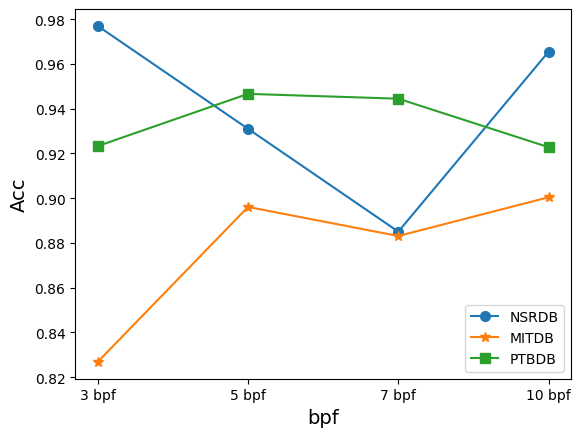

In [24]:
model_name = models_names['v2']
datasets_name = ["NSRDB", "MITDB", "PTBDB"]
bpf_list = [3, 5, 7, 10]
evaluation_metric = "Acc"
number_of_EKMs = 20

acc_bpf_variable_model_EKM_numnber(bpf_list, model_name, datasets_name, evaluation_metric, number_of_EKMs)

In [ ]:
model_name = models_names['v2']
datasets_name = ["NSRDB", "MITDB", "PTBDB"]
bpf_list = [3, 5, 7, 10]
evaluation_metric = "AUC"
number_of_EKMs = 20

acc_bpf_variable_model_EKM_numnber(bpf_list, model_name, datasets_name, evaluation_metric, number_of_EKMs)

## Plots: (Accuracy / BPF) for each **Model**

Model is the variable in the plot

EKMs amounts is constant

Dataset is constant

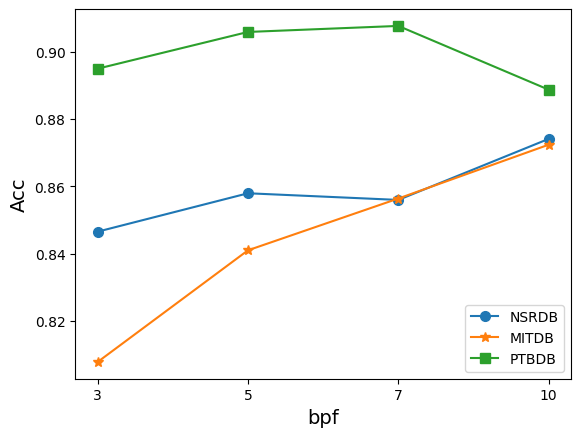

In [25]:
model_name = models_names['v3_1']
datasets_name = ["NSRDB", "MITDB", "PTBDB"]
bpf_list = [3, 5, 7, 10]
evaluation_metric = "Acc"

acc_bpf_variable_model(bpf_list, model_name, datasets_name, evaluation_metric)

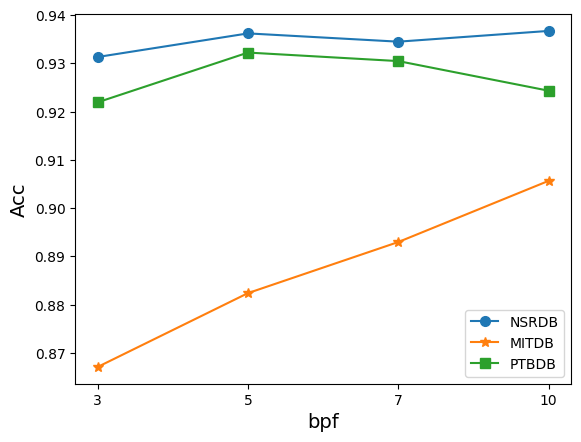

In [26]:
model_name = models_names['v2_1']
datasets_name = ["NSRDB", "MITDB", "PTBDB"]
bpf_list = [3, 5, 7, 10]
evaluation_metric = "Acc"

acc_bpf_variable_model(bpf_list, model_name, datasets_name, evaluation_metric)

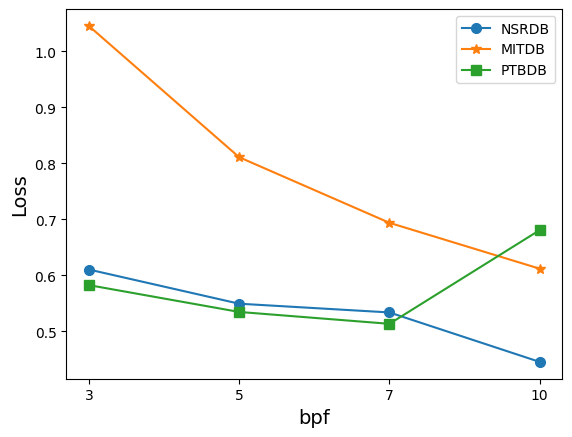

In [27]:
model_name = models_names['v3_1']
datasets_name = ["NSRDB", "MITDB", "PTBDB"]
bpf_list = [3, 5, 7, 10]
evaluation_metric = "Loss"

acc_bpf_variable_model(bpf_list, model_name, datasets_name, evaluation_metric)

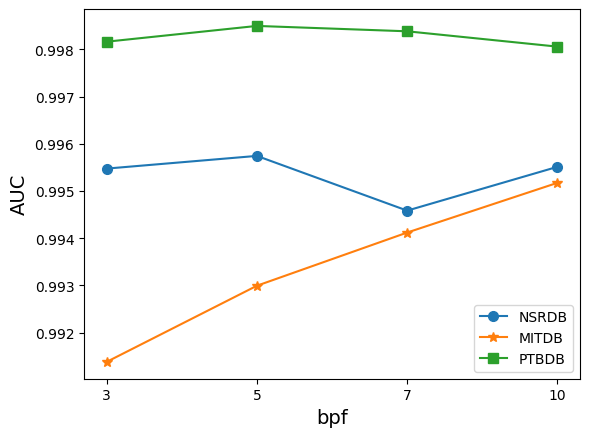

In [28]:
model_name = models_names['v2']
datasets_name = ["NSRDB", "MITDB", "PTBDB"]
bpf_list = [3, 5, 7, 10]
evaluation_metric = "AUC"

acc_bpf_variable_model(bpf_list, model_name, datasets_name, evaluation_metric)

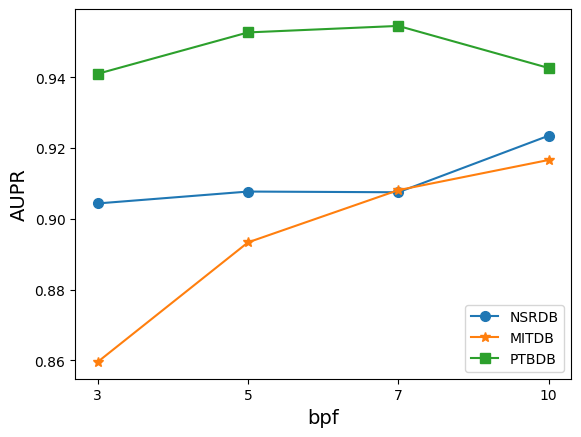

In [67]:
model_name = models_names['v3_1']
datasets_name = ["NSRDB", "MITDB", "PTBDB"]
bpf_list = [3, 5, 7, 10]
evaluation_metric = "AUPR"

acc_bpf_variable_model(bpf_list, model_name, datasets_name, evaluation_metric)

## Plots: (Accuracy / EKMs amount) for each **Model** and **Dataset**

BPF is the variable in the plot

Model is constant

Dataset is constant

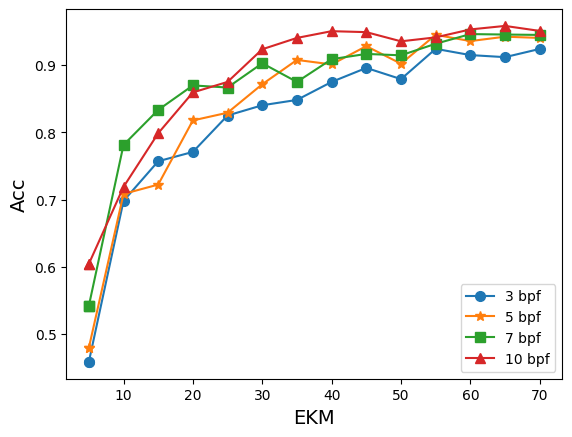

In [52]:
model_name = models_names['base']
dataset = "MITDB"
bpf = [3, 5, 7, 10]
step = 5

acc_ekms_variable_bpf_step_vised(bpf, model_name, dataset, step)

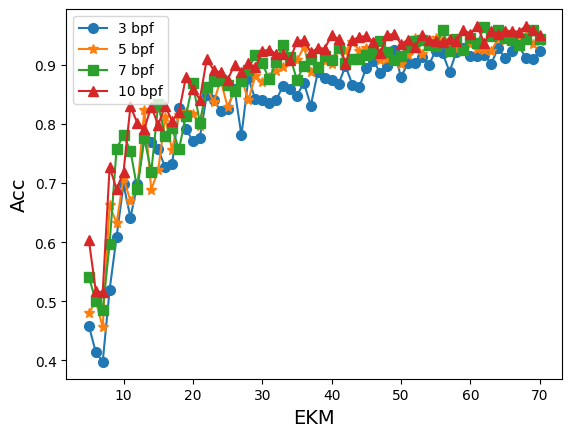

In [53]:
model_name = models_names['base']
dataset = "MITDB"
bpf = [3, 5, 7, 10]

acc_ekms_variable_bpf(bpf, model_name, dataset)

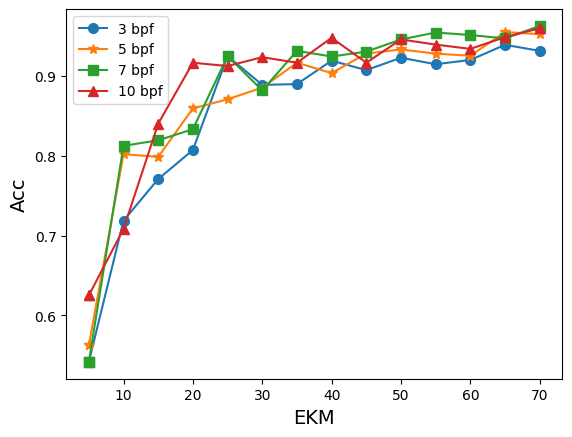

In [54]:
model_name = models_names['v2']
dataset = "MITDB"
bpf = [3, 5, 7, 10]
step = 5

acc_ekms_variable_bpf_step_vised(bpf, model_name, dataset, step)

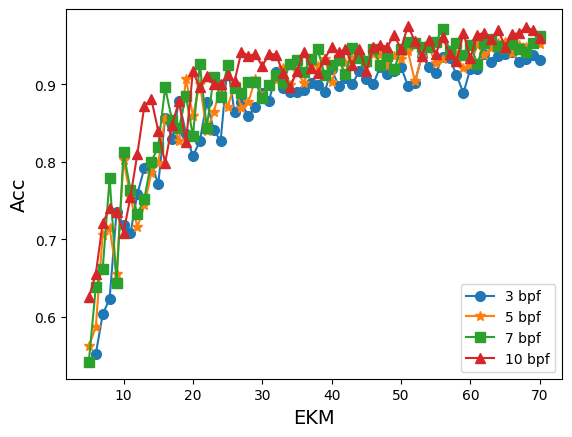

In [55]:
model_name = models_names['v2']
dataset = "MITDB"
bpf = [3, 5, 7, 10]

acc_ekms_variable_bpf(bpf, model_name, dataset)

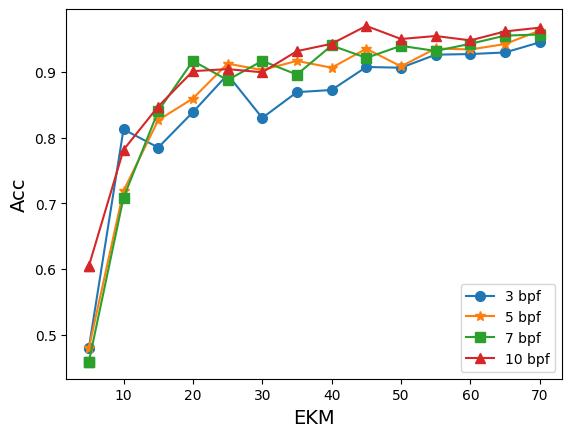

In [56]:
model_name = models_names['v2_1']
dataset = "MITDB"
bpf = [3, 5, 7, 10]
step = 5

acc_ekms_variable_bpf_step_vised(bpf, model_name, dataset, step)

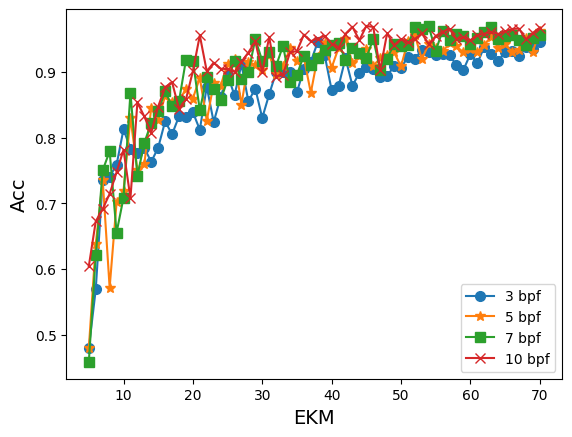

In [35]:
model_name = models_names['v2_1']
dataset = "MITDB"
bpf = [3, 5, 7, 10]

acc_ekms_variable_bpf(bpf, model_name, dataset)

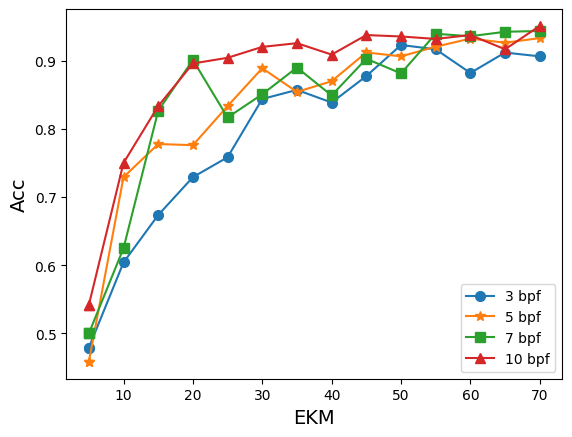

In [57]:
model_name = models_names['v3_1']
dataset = "MITDB"
bpf = [3, 5, 7, 10]
step = 5

acc_ekms_variable_bpf_step_vised(bpf, model_name, dataset, step)

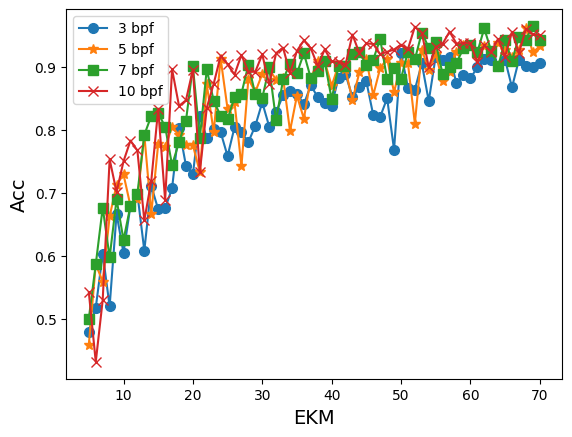

In [37]:
model_name = models_names['v3_1']
dataset = "MITDB"
bpf = [3, 5, 7, 10]

acc_ekms_variable_bpf(bpf, model_name, dataset)

## Plots: (Accuracy / EKMs amount) for each **Dataset** and **BPF of EKMs**
Model is the variable in the plot

BPF of EKMs is constant

Dataset is constant

In [58]:
def acc_ekms_mean_bpf_variable_model_versions(model_names_list, dataset_name, bpf_list, evaluation_metric):
  acc_list = []
  loss_list = []
  auc_list = []
  aupr_list = []
  step = 5

  # Reading the results files
  for bpf in bpf_list:
    temp_acc = []
    temp_loss = []
    temp_auc = []
    temp_aupr = []

    for model_name in model_names_list:
      model_name = models_names[model_name]
      path = path_geneator(model_name, bpf, dataset_name)
      raw_text_results = reading_raw_text_file(path)
      ekms_amounts, test_accuracies, test_losses, auc_scores, auprs = results_reader(raw_text_results)

      temp_acc.append(step_sampling(test_accuracies, step))
      temp_loss.append(step_sampling(test_losses, step))
      temp_auc.append(step_sampling(auc_scores, step))
      temp_aupr.append(step_sampling(auprs, step))

    acc_list.append(np.mean(temp_acc, axis=0))
    loss_list.append(np.mean(temp_loss, axis=0))
    auc_list.append(np.mean(temp_auc, axis=0))
    aupr_list.append(np.mean(temp_aupr, axis=0))

    ekms_amounts = step_sampling(ekms_amounts, step)

  paper_models_name = ["CNN-FC3", "CNN-FC4", "CNN-FC5", "LSTM-FC3"]

  # ACC vs EKMs amount
  if evaluation_metric == "Acc":
    evaluation_metric_list =  acc_list
  elif evaluation_metric == "Loss":
    evaluation_metric_list =  loss_list
  elif evaluation_metric == "AUC":
    evaluation_metric_list =  auc_list
  elif evaluation_metric == "AUPR":
    evaluation_metric_list =  aupr_list

  # ACC vs EKMs amount
  plotting(ekms_amounts,
            evaluation_metric_list,
            (evaluation_metric, 'ECM'),
            paper_models_name)

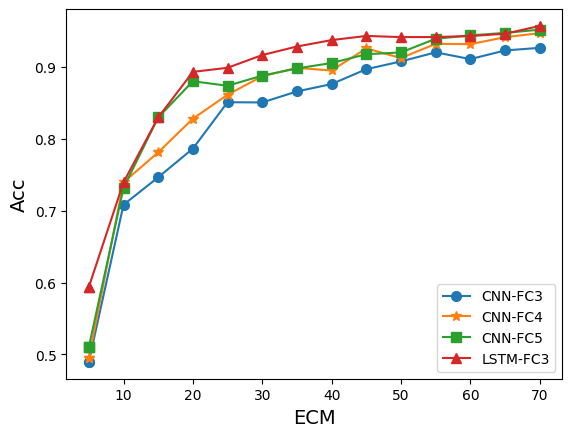

In [59]:
model_names_list = list(models_names.keys())
dataset = "MITDB"
bpf_list = [3, 5, 7, 10]
metric = "Acc"

acc_ekms_mean_bpf_variable_model_versions(model_names_list, dataset, bpf_list, metric)

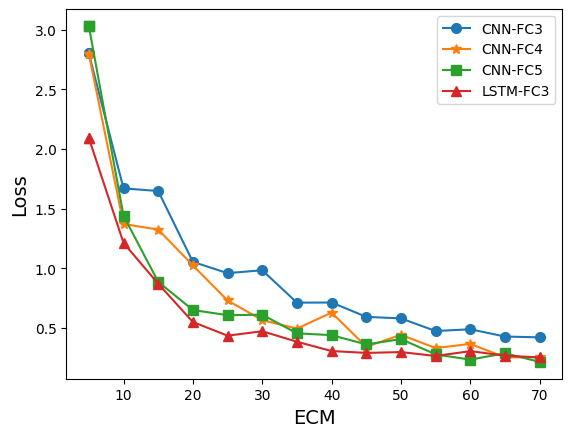

In [60]:
model_names_list = list(models_names.keys())
dataset = "MITDB"
bpf_list = [3, 5, 7, 10]
metric = "Loss"

acc_ekms_mean_bpf_variable_model_versions(model_names_list, dataset, bpf_list, metric)

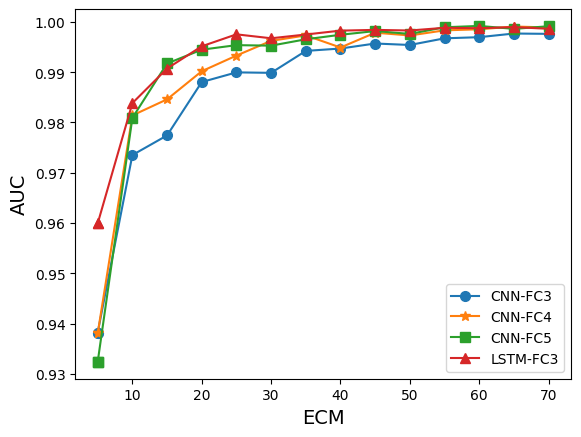

In [61]:
model_names_list = list(models_names.keys())
dataset = "MITDB"
bpf_list = [3, 5, 7, 10]
metric = "AUC"

acc_ekms_mean_bpf_variable_model_versions(model_names_list, dataset, bpf_list, metric)

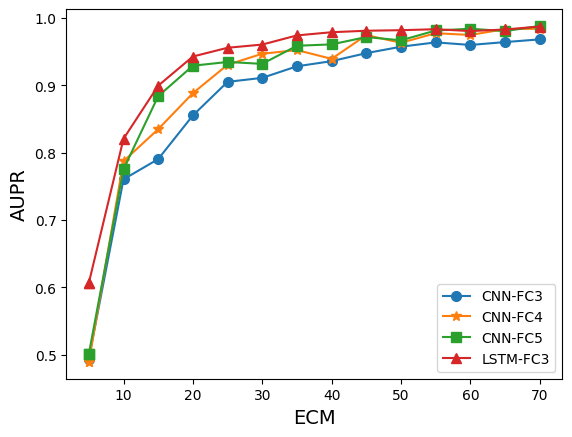

In [62]:
model_names_list = list(models_names.keys())
dataset = "MITDB"
bpf_list = [3, 5, 7, 10]
metric = "AUPR"

acc_ekms_mean_bpf_variable_model_versions(model_names_list, dataset, bpf_list, metric)

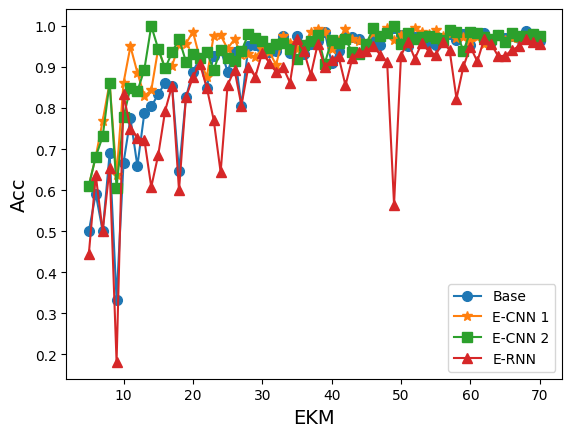

In [63]:
model_names_list = list(models_names.keys())
dataset = "NSRDB"
bpf = 3

acc_ekms_variable_model_versions(model_names_list, bpf, dataset)

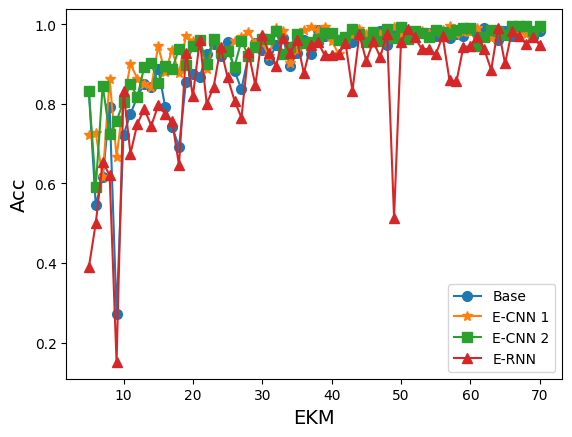

In [64]:
model_names_list = list(models_names.keys())
dataset = "NSRDB"
bpf = 5

acc_ekms_variable_model_versions(model_names_list, bpf, dataset)

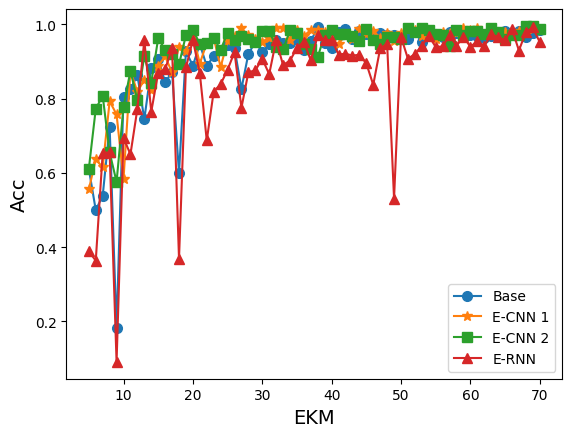

In [65]:
model_names_list = list(models_names.keys())
dataset = "NSRDB"
bpf = 7

acc_ekms_variable_model_versions(model_names_list, bpf, dataset)

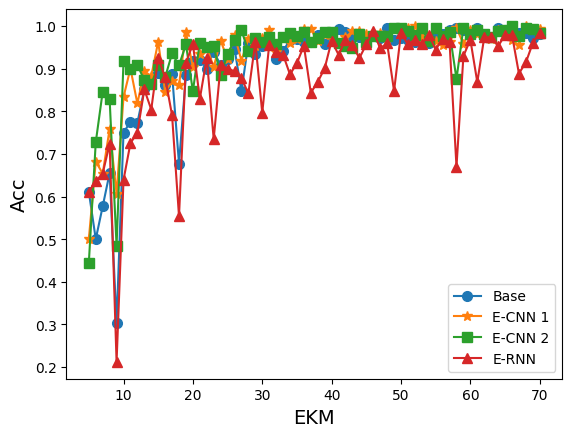

In [66]:
model_names_list = list(models_names.keys())
dataset = "NSRDB"
bpf = 10

acc_ekms_variable_model_versions(model_names_list, bpf, dataset)

## Plots: (Accuracy / EKMs amount) for each **Model** and **BPF of EKMs**
Dataset is the variable in the plot

BPF of EKMs is constant

Model is constant

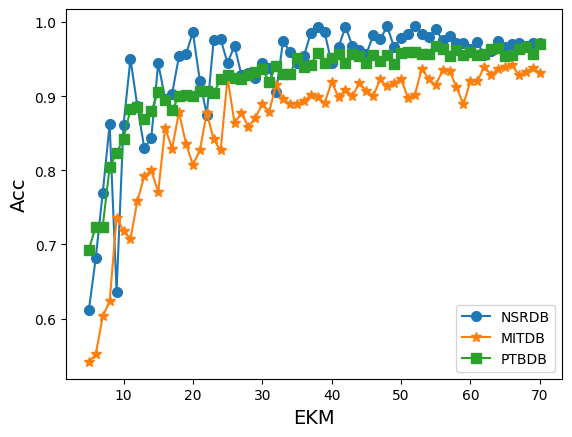

In [47]:
model_name = models_names['v2']
dataset_names = ["NSRDB", "MITDB", "PTBDB"]
bpf = 3

acc_ekms_variable_datasets(dataset_names, model_name, bpf)

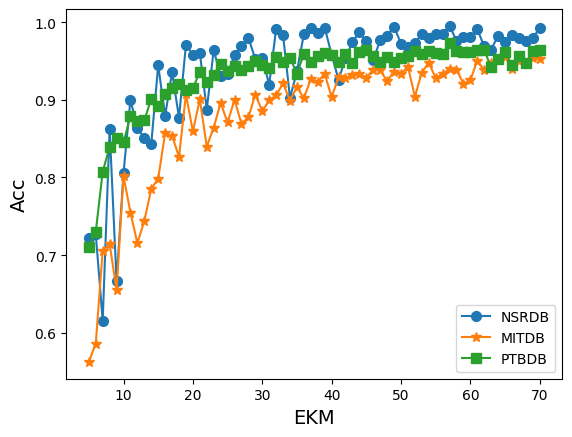

In [48]:
model_name = models_names['v2']
dataset_names = ["NSRDB", "MITDB", "PTBDB"]
bpf = 5

acc_ekms_variable_datasets(dataset_names, model_name, bpf)

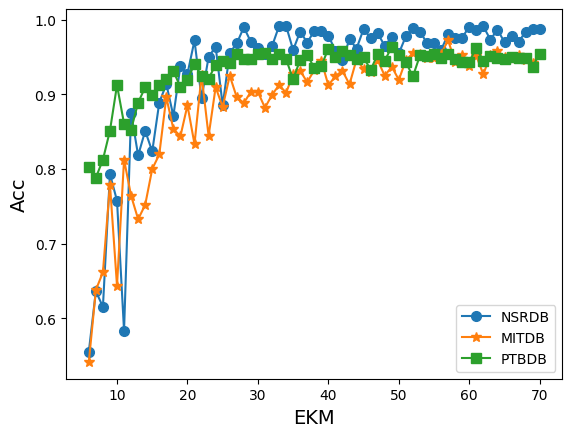

In [49]:
model_name = models_names['v2']
dataset_names = ["NSRDB", "MITDB", "PTBDB"]
bpf = 7

acc_ekms_variable_datasets(dataset_names, model_name, bpf)

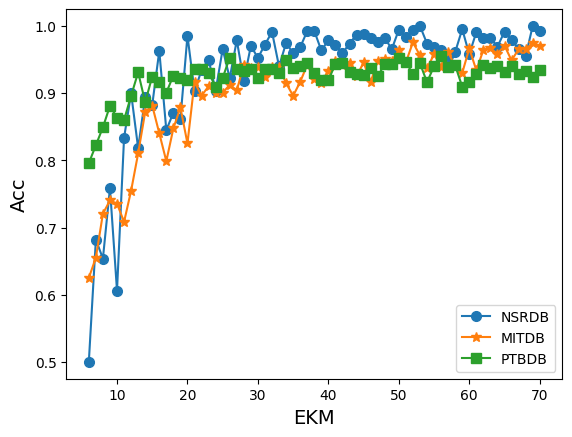

In [50]:
model_name = models_names['v2']
dataset_names = ["NSRDB", "MITDB", "PTBDB"]
bpf = 10

acc_ekms_variable_datasets(dataset_names, model_name, bpf)